In [12]:
"""
Ex. Hydrology to Multi-Geophysics Responses (Single Snapshot, 2D Profile)
=========================================================================

This example uses real hydrological model outputs from ``examples/data`` and
builds one 2D profile (single snapshot). All geophysical methods are then
simulated on the same profile:

1. Extract one 2D hydro profile from MODFLOW outputs.
2. Build one 2D mesh and interpolate hydrologic properties.
3. Simulate ERT and SRT using ``hydro_to_ert`` and ``hydro_to_srt``.
4. Simulate pseudo-2D TDEM, FDEM, and gravity using ``hydro_to_tdem``,
   ``hydro_to_fdem``, and ``hydro_to_gravity``.
"""

# sphinx_gallery_thumbnail_path = 'auto_examples/images/Ex_hydro_to_multigeophys_fig_01.png'


'\nEx. Hydrology to Multi-Geophysics Responses (Single Snapshot, 2D Profile)\n=========================================================================\n\nThis example uses real hydrological model outputs from ``examples/data`` and\nbuilds one 2D profile (single snapshot). All geophysical methods are then\nsimulated on the same profile:\n\n1. Extract one 2D hydro profile from MODFLOW outputs.\n2. Build one 2D mesh and interpolate hydrologic properties.\n3. Simulate ERT and SRT using ``hydro_to_ert`` and ``hydro_to_srt``.\n4. Simulate pseudo-2D TDEM, FDEM, and gravity using ``hydro_to_tdem``,\n   ``hydro_to_fdem``, and ``hydro_to_gravity``.\n'

## Step 1: Imports


In [13]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pygimli as pg
from pygimli.physics import ert
import pygimli.physics.traveltime as tt
from scipy.interpolate import griddata

# Setup package path for development
try:
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    current_dir = os.getcwd()

parent_dir = os.path.dirname(current_dir)
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from PyHydroGeophysX.core.interpolation import ProfileInterpolator, create_surface_lines
from PyHydroGeophysX.core.mesh_utils import MeshCreator
from PyHydroGeophysX.Hydro_modular import (
    hydro_to_ert,
    hydro_to_srt,
    hydro_to_tdem,
    hydro_to_fdem,
    hydro_to_gravity,
)


In [14]:
output_dir = os.path.join(current_dir, "results", "hydro_to_multigeophys")
os.makedirs(output_dir, exist_ok=True)

rng_seed = 7


## Step 2: Helper Functions


In [15]:
def fill_profile_nans(values):
    """Fill NaNs along profile direction for each layer."""
    arr = np.asarray(values, dtype=float).copy()
    if arr.ndim != 2:
        raise ValueError(f"Expected 2D array, got shape {arr.shape}.")

    x = np.arange(arr.shape[1], dtype=float)
    for i in range(arr.shape[0]):
        row = arr[i, :]
        valid = np.isfinite(row)
        if np.any(valid):
            if np.count_nonzero(valid) == 1:
                row[~valid] = row[valid][0]
            else:
                row[~valid] = np.interp(x[~valid], x[valid], row[valid])
        else:
            raise RuntimeError("Profile interpolation failed: one layer is all NaN.")
        arr[i, :] = row

    return arr


def get_mesh_xy(mesh):
    """Return mesh cell-center x/y arrays."""
    centers = np.asarray(mesh.cellCenters(), dtype=float)
    if centers.ndim == 2 and centers.shape[1] >= 2:
        return centers[:, 0], centers[:, 1]

    x = np.array([float(c[0]) for c in mesh.cellCenters()], dtype=float)
    y = np.array([float(c[1]) for c in mesh.cellCenters()], dtype=float)
    return x, y


def assign_three_layer_markers(mesh, line1, line2, top_marker=0, mid_marker=3, bot_marker=2):
    """Assign top/middle/bottom markers from two interface lines."""
    x_cell, y_cell = get_mesh_xy(mesh)

    y_line1 = np.interp(x_cell, line1[:, 0], line1[:, 1])
    y_line2 = np.interp(x_cell, line2[:, 0], line2[:, 1])

    markers = np.full(mesh.cellCount(), bot_marker, dtype=int)
    markers[y_cell >= y_line2] = mid_marker
    markers[y_cell >= y_line1] = top_marker

    mesh.setCellMarkers(markers)
    return markers


def interpolate_profile_to_mesh(profile_values, layer_boundaries, x_profile, mesh):
    """Interpolate profile matrix (layers x distance) to mesh cells."""
    values = np.asarray(profile_values, dtype=float)
    bounds = np.asarray(layer_boundaries, dtype=float)

    n_layers, n_profile = values.shape
    if bounds.shape != (n_layers + 1, n_profile):
        raise ValueError(
            f"layer_boundaries shape must be {(n_layers + 1, n_profile)}, got {bounds.shape}."
        )

    layer_centers = 0.5 * (bounds[:-1, :] + bounds[1:, :])
    x2d = np.repeat(np.asarray(x_profile, dtype=float)[np.newaxis, :], n_layers, axis=0)

    points = np.column_stack((x2d.ravel(), layer_centers.ravel()))
    vals = values.ravel()

    x_cell, y_cell = get_mesh_xy(mesh)
    query = np.column_stack((x_cell, y_cell))

    interp_linear = griddata(points, vals, query, method="linear")
    interp_nearest = griddata(points, vals, query, method="nearest")

    out = np.asarray(interp_linear, dtype=float)
    nan_mask = ~np.isfinite(out)
    out[nan_mask] = interp_nearest[nan_mask]
    return out


def relative_l2(noisy, clean):
    noisy_arr = np.asarray(noisy)
    clean_arr = np.asarray(clean)
    denom = np.linalg.norm(clean_arr)
    if denom <= 0:
        return np.nan
    return float(np.linalg.norm(noisy_arr - clean_arr) / denom)


## Step 3: Load Real Model Outputs and Build One 2D Profile


In [16]:
data_dir = os.path.join(current_dir, "data")
water_content_4d = np.load(os.path.join(data_dir, "Watercontent.npy"))
porosity_3d = np.load(os.path.join(data_dir, "Porosity.npy"))
top = np.loadtxt(os.path.join(data_dir, "top.txt"))
bot = np.load(os.path.join(data_dir, "bot.npy"))

snapshot_index = 5
water_content_3d = np.asarray(water_content_4d[snapshot_index], dtype=float)

point1 = [115, 70]
point2 = [95, 180]
interpolator = ProfileInterpolator(
    point1=point1,
    point2=point2,
    surface_data=top,
    origin_x=0.0,
    origin_y=0.0,
    pixel_width=1.0,
    pixel_height=-1.0,
    num_points=220,
)

structure = interpolator.interpolate_layer_data([top] + [bot[i] for i in range(bot.shape[0])])
water_content_profile = interpolator.interpolate_3d_data(water_content_3d)
porosity_profile = interpolator.interpolate_3d_data(porosity_3d)

structure = fill_profile_nans(structure)
water_content_profile = np.clip(fill_profile_nans(water_content_profile), 0.0, 0.8)
porosity_profile = np.clip(fill_profile_nans(porosity_profile), 0.01, 0.6)

L_profile = np.asarray(interpolator.L_profile, dtype=float)
n_layers, n_profile = water_content_profile.shape

n_bounds = structure.shape[0]
mid_idx = max(1, min(4, n_bounds // 3))
bot_idx = max(mid_idx + 1, min(12, n_bounds - 2))

surface, line1, line2 = create_surface_lines(
    L_profile=L_profile,
    structure=structure,
    top_idx=0,
    mid_idx=mid_idx,
    bot_idx=bot_idx,
)

mesh_creator = MeshCreator(quality=32, area=1.0)
mesh, _ = mesh_creator.create_from_layers(
    surface=surface,
    layers=[line1, line2],
    bottom_depth=float(np.min(line2[:, 1]) - 10.0),
)

mesh_markers = assign_three_layer_markers(mesh, line1, line2, top_marker=0, mid_marker=3, bot_marker=2)

wc_mesh = interpolate_profile_to_mesh(water_content_profile, structure, L_profile, mesh)
porosity_mesh = interpolate_profile_to_mesh(porosity_profile, structure, L_profile, mesh)

print(f"water_content_3d shape: {water_content_3d.shape}")
print(f"porosity_3d shape:      {porosity_3d.shape}")
print(f"Profile points:         {n_profile}")
print(f"Mesh cells:             {mesh.cellCount()}")
print(f"Water content range:    {np.nanmin(water_content_profile):.4f} - {np.nanmax(water_content_profile):.4f}")
print(f"Porosity range:         {np.nanmin(porosity_profile):.4f} - {np.nanmax(porosity_profile):.4f}")


water_content_3d shape: (14, 194, 157)
porosity_3d shape:      (14, 194, 157)
Profile points:         219
Mesh cells:             12746
Water content range:    0.0392 - 0.2661
Porosity range:         0.0500 - 0.4500


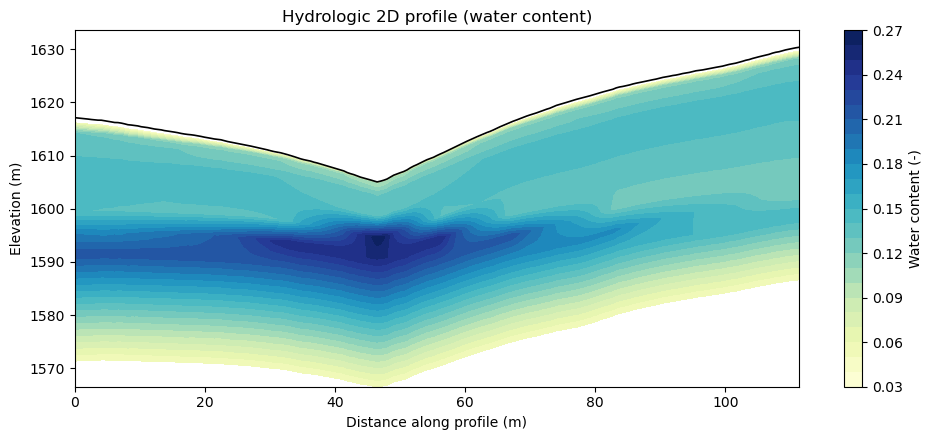

In [17]:
layer_centers = 0.5 * (structure[:-1, :] + structure[1:, :])
X2D = np.repeat(L_profile[np.newaxis, :], n_layers, axis=0)

fig, ax = plt.subplots(figsize=(10, 4.5))
cf = ax.contourf(X2D, layer_centers, water_content_profile, levels=25, cmap="YlGnBu")
ax.plot(L_profile, structure[0, :], "k-", lw=1.2)
ax.set_title("Hydrologic 2D profile (water content)")
ax.set_xlabel("Distance along profile (m)")
ax.set_ylabel("Elevation (m)")
cb = plt.colorbar(cf, ax=ax)
cb.set_label("Water content (-)")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "Ex_hydro_to_multigeophys_fig_01.png"), dpi=220, bbox_inches="tight")
plt.show()


## Step 4: ERT and SRT from the Same 2D Profile (`hydro_to_ert`, `hydro_to_srt`)


In [18]:
rho_parameters = {
    "rho_sat": [100.0, 500.0, 2400.0],
    "n": [2.2, 1.8, 2.5],
    "sigma_s": [1.0 / 500.0, 0.0, 0.0],
}

vel_parameters = {
    "top": {
        "bulk_modulus": 30.0,
        "shear_modulus": 20.0,
        "mineral_density": 2650,
        "depth": 1.0,
    },
    "mid": {
        "bulk_modulus": 50.0,
        "shear_modulus": 35.0,
        "mineral_density": 2670,
        "aspect_ratio": 0.05,
    },
    "bot": {
        "bulk_modulus": 55.0,
        "shear_modulus": 50.0,
        "mineral_density": 2680,
        "aspect_ratio": 0.03,
    },
}

layer_markers = [0, 3, 2]

srt_data, velocity_model = hydro_to_srt(
    water_content=wc_mesh,
    porosity=porosity_mesh,
    mesh=mesh,
    profile_interpolator=interpolator,
    layer_idx=[0, mid_idx, bot_idx],
    structure=structure,
    marker_labels=layer_markers,
    vel_parameters=vel_parameters,
    sensor_spacing=1.0,
    sensor_start=15.0,
    num_sensors=72,
    shot_distance=5,
    noise_level=0.01,
    noise_abs=1e-5,
    mesh_markers=mesh_markers,
    verbose=False,
    seed=rng_seed,
)

ert_data, resistivity_model = hydro_to_ert(
    water_content=wc_mesh,
    porosity=porosity_mesh,
    mesh=mesh,
    profile_interpolator=interpolator,
    layer_idx=[0, mid_idx, bot_idx],
    structure=structure,
    marker_labels=layer_markers,
    rho_parameters=rho_parameters,
    electrode_spacing=1.0,
    electrode_start=15.0,
    num_electrodes=72,
    scheme_name="wa",
    noise_level=0.03,
    abs_error=0.0,
    rel_error=0.03,
    mesh_markers=mesh_markers,
    verbose=False,
    seed=rng_seed,
)

print(f"ERT data count: {ert_data.size()}")
print(f"SRT data count: {srt_data.size()}")


15/02/26 - 14:37:12 - pyGIMLi - INFO - Creating refined mesh (secnodes: 2) to solve forward task.
15/02/26 - 14:37:20 - pyGIMLi - INFO - Found 2 regions.
15/02/26 - 14:37:20 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
15/02/26 - 14:37:20 - pyGIMLi - INFO - Found 2 regions.
15/02/26 - 14:37:20 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
15/02/26 - 14:37:20 - pyGIMLi - INFO - Creating forward mesh from region infos.
15/02/26 - 14:37:20 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
15/02/26 - 14:37:21 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 28640 Cells: 56788 Boundaries: 42836


ERT data count: 828
SRT data count: 1065


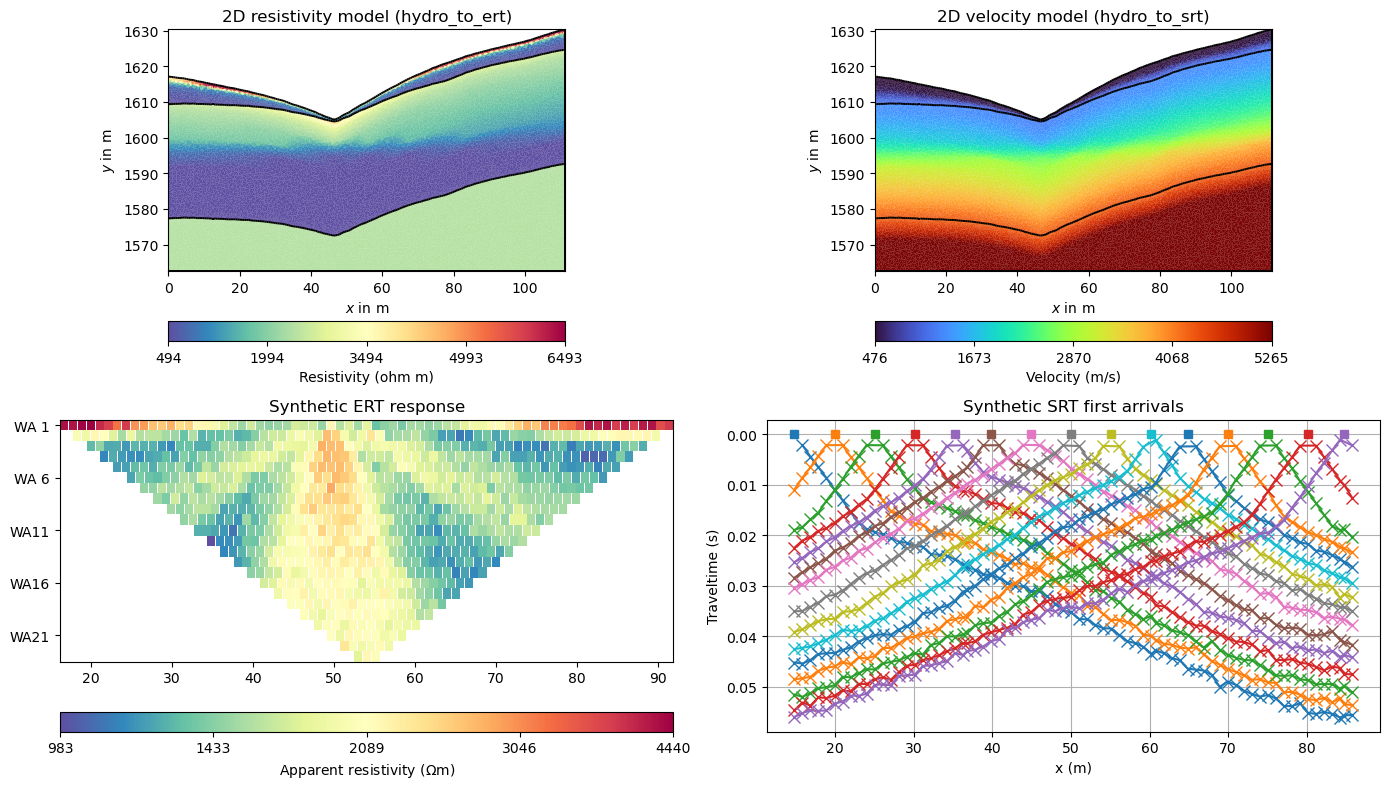

In [19]:
fig = plt.figure(figsize=(14, 8))
ax1 = fig.add_subplot(2, 2, 1)
pg.show(
    mesh,
    resistivity_model,
    ax=ax1,
    cMap="Spectral_r",
    label="Resistivity (ohm m)",
)
ax1.set_title("2D resistivity model (hydro_to_ert)")

ax2 = fig.add_subplot(2, 2, 2)
pg.show(
    mesh,
    velocity_model,
    ax=ax2,
    cMap="turbo",
    label="Velocity (m/s)",
)
ax2.set_title("2D velocity model (hydro_to_srt)")

ax3 = fig.add_subplot(2, 2, 3)
ert.show(ert_data, ax=ax3)
ax3.set_title("Synthetic ERT response")

ax4 = fig.add_subplot(2, 2, 4)
tt.drawFirstPicks(ax4, srt_data)
ax4.set_title("Synthetic SRT first arrivals")

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "ert_srt_2d_profile.png"), dpi=220, bbox_inches="tight")
plt.show()


## Step 5: Pseudo-2D TDEM / FDEM / Gravity from the Same Profile


In [20]:
step = max(1, n_profile // 24)
station_idx = np.unique(np.r_[np.arange(0, n_profile, step), n_profile - 1])

x_station = L_profile[station_idx]
wc_station = water_content_profile[:, station_idx]
por_station = porosity_profile[:, station_idx]
structure_station = structure[:, station_idx]

times = np.logspace(-5, -2, 28)
frequencies = np.logspace(1, 4, 18)

tdem_noisy, tdem_clean, tdem_unc, tdem_cond = hydro_to_tdem(
    water_content=wc_station,
    porosity=por_station,
    layer_boundaries=structure_station,
    times=times,
    sigma_w=0.05,
    m=1.5,
    n=2.0,
    sigma_s=0.0,
    source_radius=10.0,
    noise_level=0.03,
    seed=rng_seed,
    verbose=False,
)

fdem_noisy, fdem_clean, fdem_unc, fdem_cond = hydro_to_fdem(
    water_content=wc_station,
    porosity=por_station,
    layer_boundaries=structure_station,
    frequencies=frequencies,
    sigma_w=0.05,
    m=1.5,
    n=2.0,
    sigma_s=0.0,
    source_location=np.array([0.0, 0.0, 0.0]),
    receiver_location=np.array([12.0, 0.0, 0.0]),
    receiver_component="secondary",
    waveform_type="dipole",
    noise_level=0.03,
    seed=rng_seed,
    verbose=False,
)

grav_noisy, grav_clean, grav_unc, density_contrast = hydro_to_gravity(
    water_content=wc_station,
    porosity=por_station,
    layer_boundaries=structure_station,
    station_positions=x_station,
    rho_matrix=2650.0,
    rho_water=1000.0,
    rho_air=1.225,
    sensor_height=1.0,
    noise_level=0.02,
    seed=rng_seed,
    verbose=False,
)

print(f"TDEM matrix shape: {tdem_clean.shape}, relative L2 noise = {relative_l2(tdem_noisy, tdem_clean):.4f}")
print(f"FDEM matrix shape: {fdem_clean.shape}, relative L2 noise = {relative_l2(fdem_noisy, fdem_clean):.4f}")
print(f"Gravity range (mGal): {np.min(grav_clean):.5f} to {np.max(grav_clean):.5f}")


TDEM matrix shape: (26, 28), relative L2 noise = 0.0277
FDEM matrix shape: (26, 18), relative L2 noise = 0.0398
Gravity range (mGal): -0.06029 to -0.02662


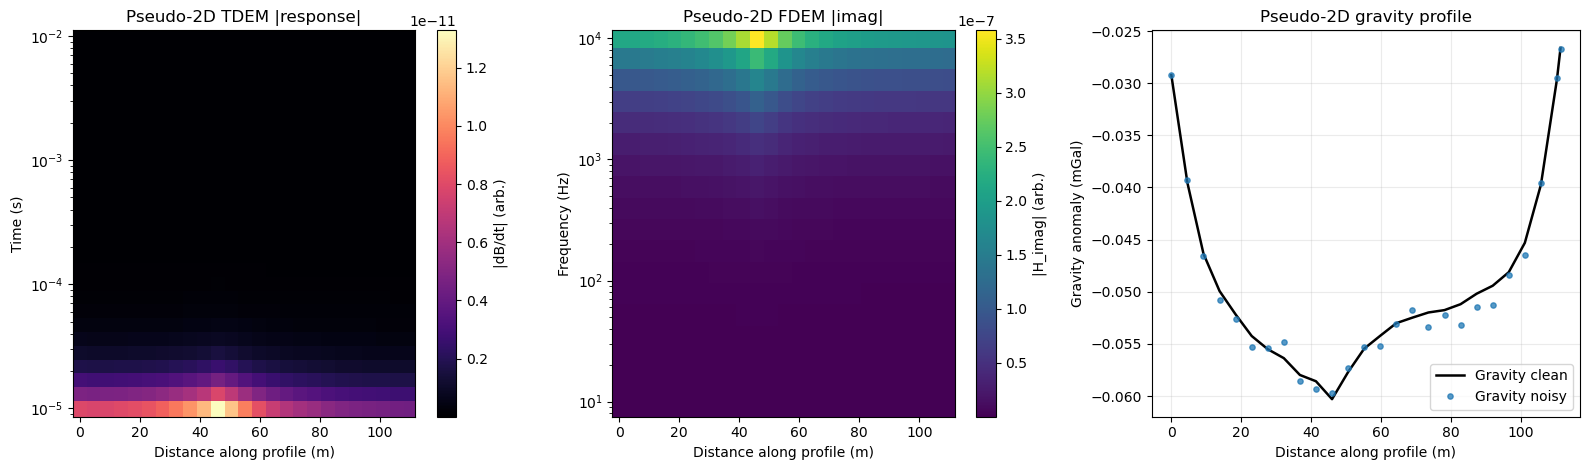

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

im0 = axes[0].pcolormesh(
    x_station,
    times,
    np.abs(tdem_clean).T,
    shading="auto",
    cmap="magma",
)
axes[0].set_yscale("log")
axes[0].set_xlabel("Distance along profile (m)")
axes[0].set_ylabel("Time (s)")
axes[0].set_title("Pseudo-2D TDEM |response|")
cb0 = plt.colorbar(im0, ax=axes[0])
cb0.set_label("|dB/dt| (arb.)")

im1 = axes[1].pcolormesh(
    x_station,
    frequencies,
    np.abs(np.imag(fdem_clean)).T,
    shading="auto",
    cmap="viridis",
)
axes[1].set_yscale("log")
axes[1].set_xlabel("Distance along profile (m)")
axes[1].set_ylabel("Frequency (Hz)")
axes[1].set_title("Pseudo-2D FDEM |imag|")
cb1 = plt.colorbar(im1, ax=axes[1])
cb1.set_label("|H_imag| (arb.)")

axes[2].plot(x_station, grav_clean, "k-", lw=1.8, label="Gravity clean")
axes[2].plot(x_station, grav_noisy, "o", ms=3.8, alpha=0.75, label="Gravity noisy")
axes[2].set_xlabel("Distance along profile (m)")
axes[2].set_ylabel("Gravity anomaly (mGal)")
axes[2].set_title("Pseudo-2D gravity profile")
axes[2].grid(True, alpha=0.25)
axes[2].legend(loc="best")

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "em_gravity_2d_profile.png"), dpi=220, bbox_inches="tight")
plt.show()


Summary:
This workflow uses one real MODFLOW snapshot and one 2D extracted profile.
ERT and SRT are simulated directly from the same 2D profile.
TDEM, FDEM, and gravity are simulated along the same profile in a
pseudo-2D representation.
